In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Install shap if not available (run once)
# !pip install shap -q

# Create visualization folder
viz_dir = '../visualization/'
os.makedirs(viz_dir, exist_ok=True)
print(f"✅ Created folder: {viz_dir}")

✅ Created folder: ../visualization/


In [2]:
# ============================================================
# STEP 1: LOAD DATA AND MODEL
# ============================================================

# Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Load trained XGBoost model
xgb_model = joblib.load('../models/xgboost_sales_model.pkl')

# Load original data for time series analysis
train = pd.read_csv('../data/raw/train.csv')
store = pd.read_csv('../data/raw/store.csv')
df = train.merge(store, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Open'] == 1]  # Remove closed stores

# Create sample for fast visualization
SAMPLE_SIZE = 5000
X_test_sample = X_test.sample(n=SAMPLE_SIZE, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

# Generate predictions
y_pred_xgb = xgb_model.predict(X_test_sample)

print(f"✅ Loaded: X_test {X_test.shape}, Model: XGBoost")
print(f"✅ Sample for viz: {SAMPLE_SIZE} rows")

C:\Users\USER\AppData\Local\Temp\ipykernel_14508\696990236.py:15: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('../data/raw/train.csv')


✅ Loaded: X_test (196032, 25), Model: XGBoost
✅ Sample for viz: 5000 rows


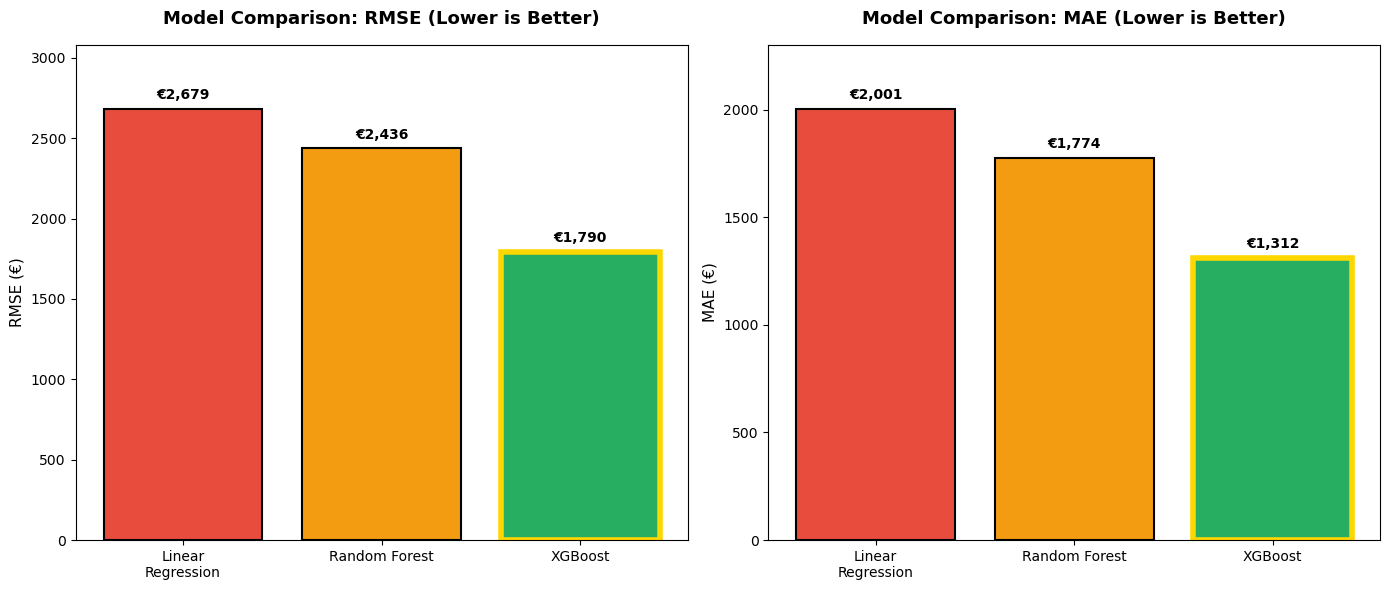

✅ Saved: 01_model_comparison.png


In [3]:
# ============================================================
# CHART 1: MODEL COMPARISON (Your actual results)
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Your actual results from training
models = ['Linear\nRegression', 'Random Forest', 'XGBoost']
rmse = [2678.76, 2436.06, 1790.43]
mae = [2001.17, 1774.40, 1312.11]

# RMSE comparison
colors = ['#e74c3c', '#f39c12', '#27ae60']
bars1 = ax1.bar(models, rmse, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Model Comparison: RMSE (Lower is Better)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('RMSE (€)', fontsize=11)
ax1.set_ylim(0, max(rmse) * 1.15)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'€{height:,.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Highlight winner
bars1[2].set_edgecolor('gold')
bars1[2].set_linewidth(4)

# MAE comparison
bars2 = ax2.bar(models, mae, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Model Comparison: MAE (Lower is Better)', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('MAE (€)', fontsize=11)
ax2.set_ylim(0, max(mae) * 1.15)

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'€{height:,.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Highlight winner
bars2[2].set_edgecolor('gold')
bars2[2].set_linewidth(4)

plt.tight_layout()
plt.savefig(f'{viz_dir}01_model_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: 01_model_comparison.png")

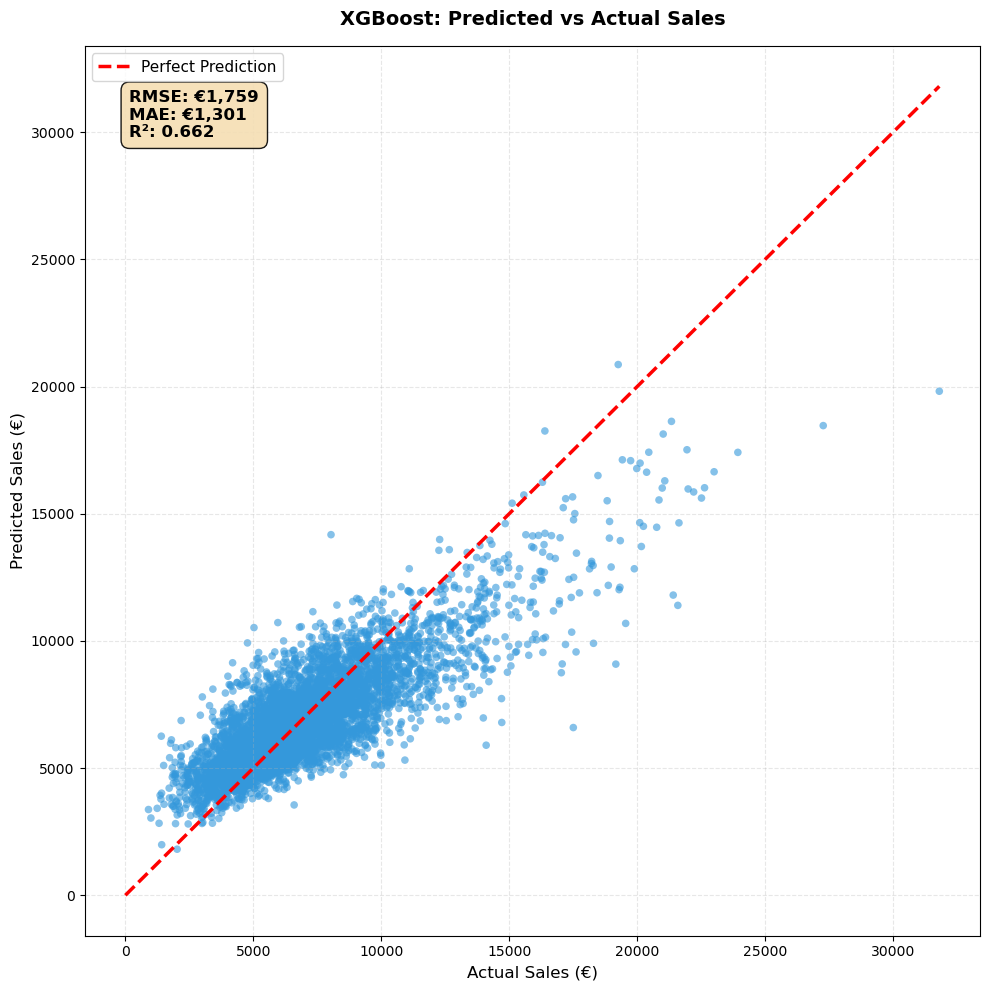

✅ Saved: 02_prediction_vs_actual.png


In [4]:
# ============================================================
# CHART 2: PREDICTED VS ACTUAL (XGBoost accuracy)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 10))

# Scatter plot
ax.scatter(y_test_sample, y_pred_xgb, alpha=0.6, s=30, color='#3498db', edgecolor='none')

# Perfect prediction line
max_val = max(y_test_sample.max(), y_pred_xgb.max())
ax.plot([0, max_val], [0, max_val], 'r--', lw=2.5, label='Perfect Prediction')

# Formatting
ax.set_xlabel('Actual Sales (€)', fontsize=12)
ax.set_ylabel('Predicted Sales (€)', fontsize=12)
ax.set_title('XGBoost: Predicted vs Actual Sales', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

# Add metrics box
rmse = np.sqrt(np.mean((y_test_sample - y_pred_xgb) ** 2))
mae = np.mean(np.abs(y_test_sample - y_pred_xgb))
r2 = 1 - (np.sum((y_test_sample - y_pred_xgb) ** 2) / np.sum((y_test_sample - y_test_sample.mean()) ** 2))

textstr = f'RMSE: €{rmse:,.0f}\nMAE: €{mae:,.0f}\nR²: {r2:.3f}'
props = dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.9, edgecolor='black')
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{viz_dir}02_prediction_vs_actual.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: 02_prediction_vs_actual.png")


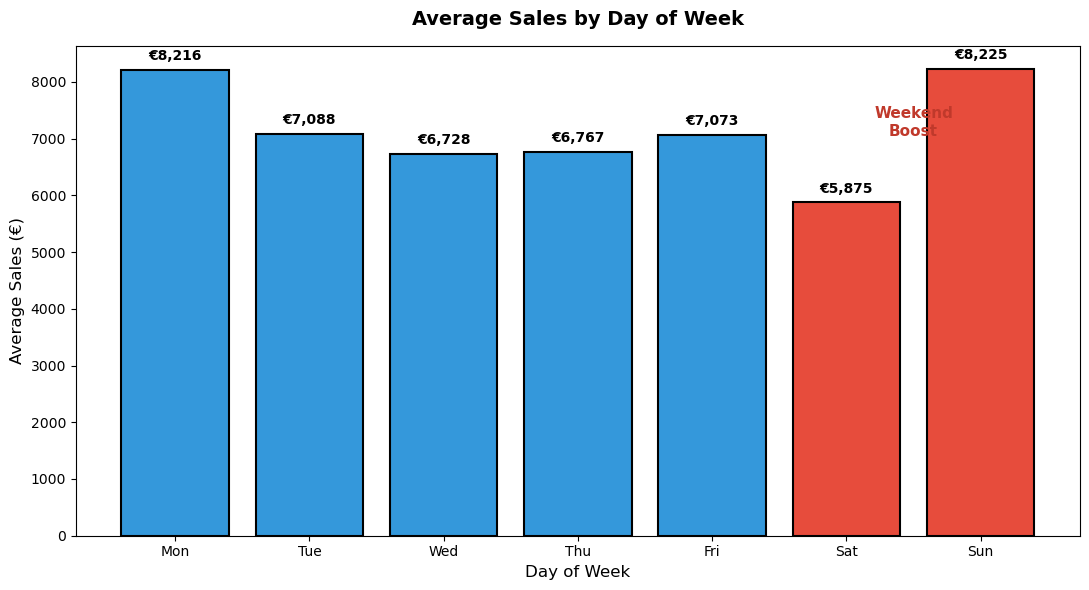

✅ Saved: 03_sales_by_day.png


In [5]:
# ============================================================
# CHART 3: SALES BY DAY OF WEEK (Business pattern)
# ============================================================

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_avg = df.groupby('DayOfWeek')['Sales'].mean()

fig, ax = plt.subplots(figsize=(11, 6))

# Weekdays blue, weekends red
bar_colors = ['#3498db'] * 5 + ['#e74c3c'] * 2
bars = ax.bar(day_names, daily_avg, color=bar_colors, edgecolor='black', linewidth=1.5)

ax.set_title('Average Sales by Day of Week', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Average Sales (€)', fontsize=12)
ax.set_xlabel('Day of Week', fontsize=12)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'€{height:,.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add weekend highlight text
ax.annotate('Weekend\nBoost', xy=(5.5, daily_avg.iloc[5:].mean()), 
            fontsize=11, ha='center', color='#c0392b', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{viz_dir}03_sales_by_day.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: 03_sales_by_day.png")


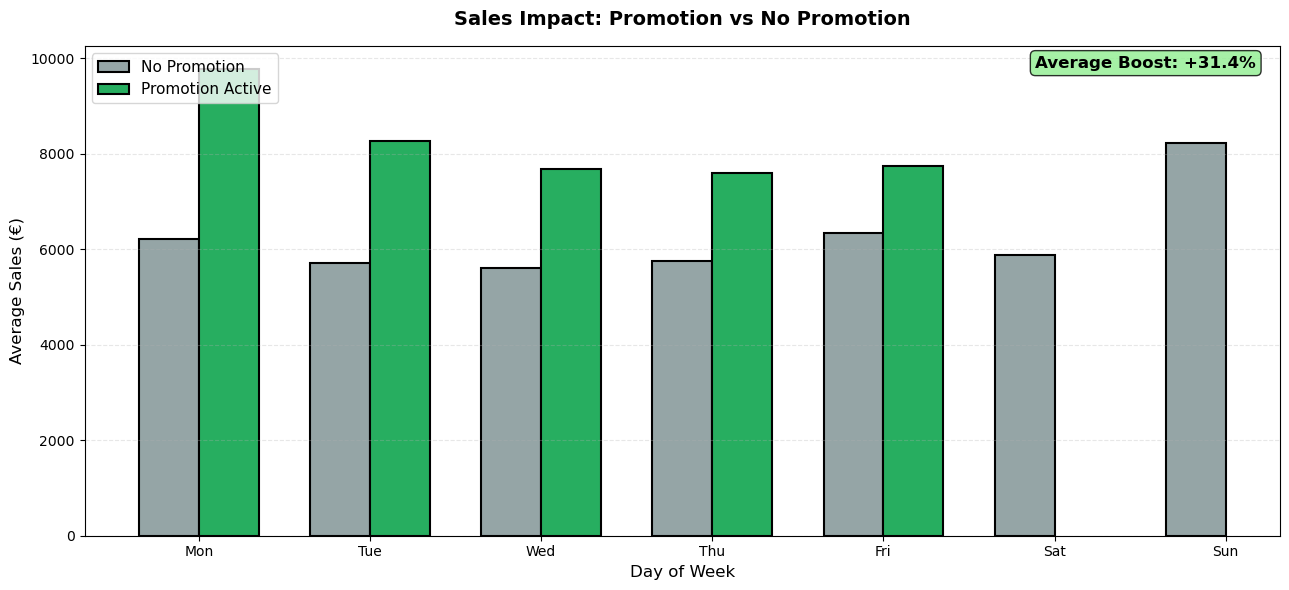

✅ Saved: 04_promotion_impact.png


In [6]:
# ============================================================
# CHART 4: PROMOTION IMPACT ANALYSIS
# ============================================================

promo_impact = df.groupby(['Promo', 'DayOfWeek'])['Sales'].mean().unstack()

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(7)
width = 0.35

no_promo = promo_impact.loc[0]
yes_promo = promo_impact.loc[1]

bars1 = ax.bar(x - width/2, no_promo, width, label='No Promotion', 
               color='#95a5a6', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, yes_promo, width, label='Promotion Active', 
               color='#27ae60', edgecolor='black', linewidth=1.5)

ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Sales (€)', fontsize=12)
ax.set_title('Sales Impact: Promotion vs No Promotion', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(day_names)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Calculate and display average boost
avg_boost = (yes_promo.mean() - no_promo.mean()) / no_promo.mean() * 100
ax.text(0.98, 0.98, f'Average Boost: +{avg_boost:.1f}%', 
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{viz_dir}04_promotion_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: 04_promotion_impact.png")


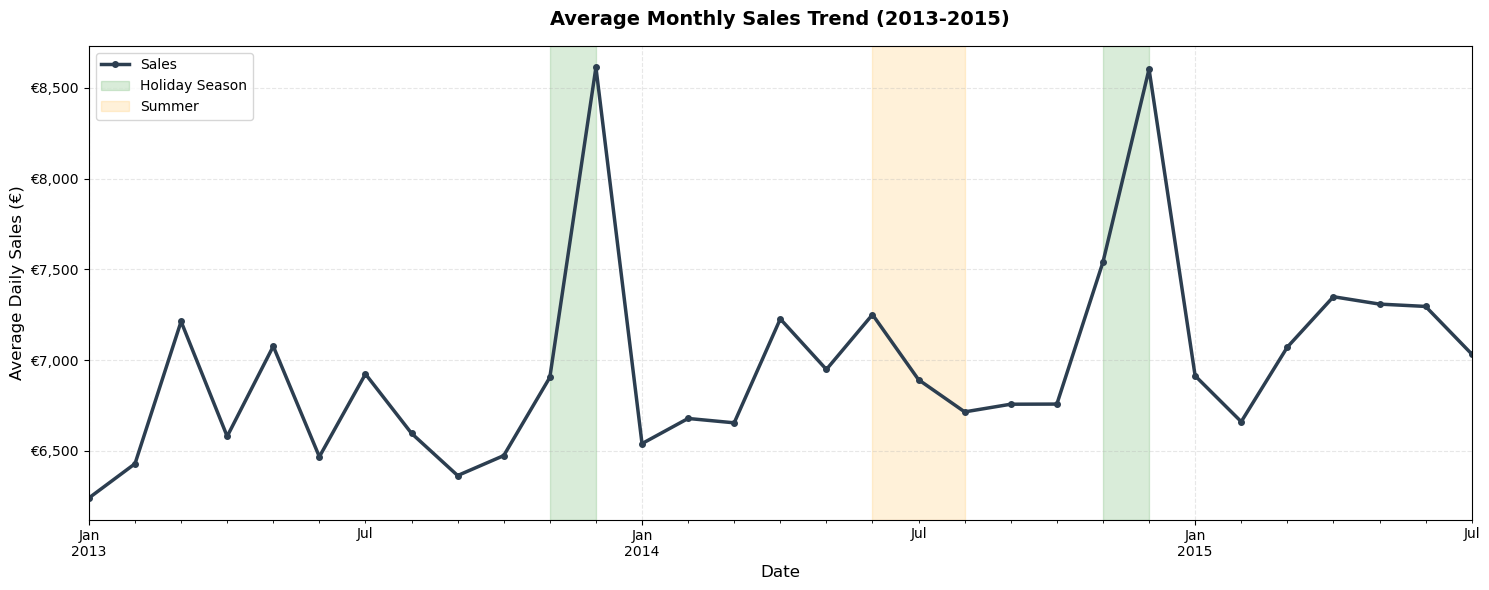

✅ Saved: 05_monthly_trend.png


In [7]:
# ============================================================
# CHART 5: MONTHLY SALES TREND (Time series)
# ============================================================

monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Sales'].mean()

fig, ax = plt.subplots(figsize=(15, 6))
monthly_sales.plot(ax=ax, color='#2c3e50', linewidth=2.5, marker='o', markersize=4)

# Highlight holiday seasons
ax.axvspan(pd.Period('2013-11'), pd.Period('2013-12'), alpha=0.15, color='green', label='Holiday Season')
ax.axvspan(pd.Period('2014-11'), pd.Period('2014-12'), alpha=0.15, color='green')
ax.axvspan(pd.Period('2014-06'), pd.Period('2014-08'), alpha=0.15, color='orange', label='Summer')

ax.set_title('Average Monthly Sales Trend (2013-2015)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average Daily Sales (€)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))

plt.tight_layout()
plt.savefig(f'{viz_dir}05_monthly_trend.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: 05_monthly_trend.png")

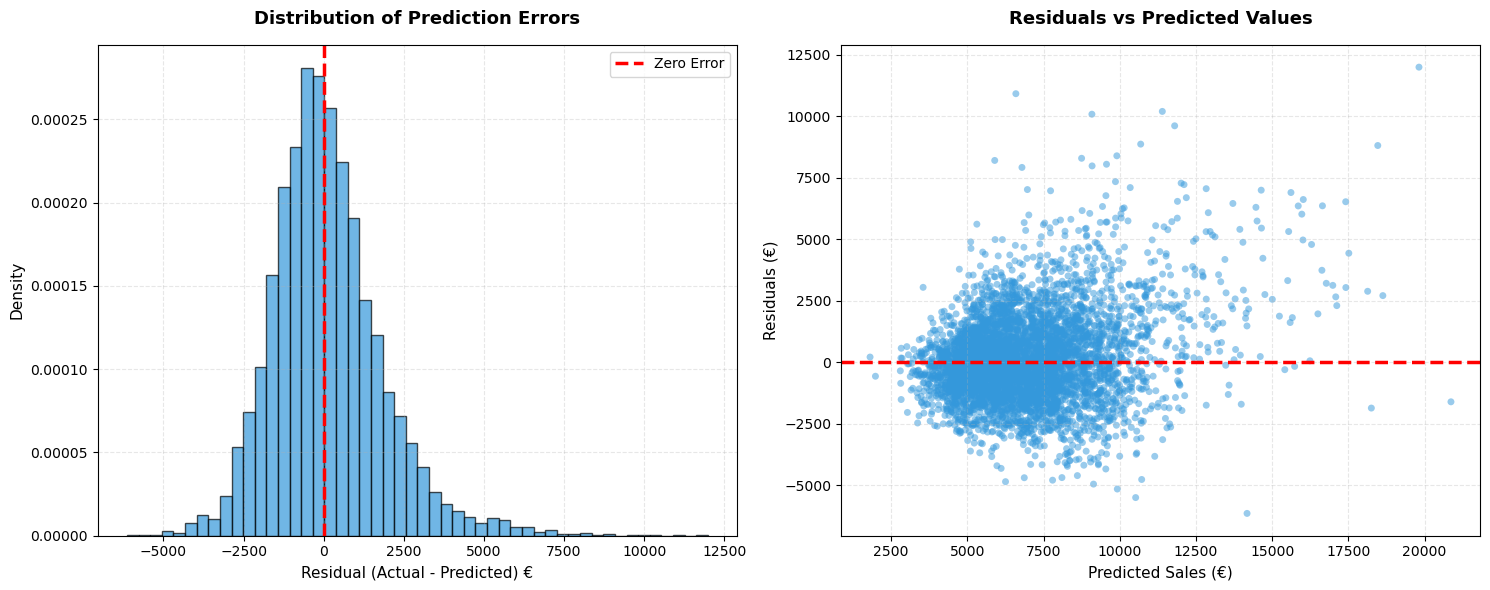

✅ Saved: 06_residuals_analysis.png


In [8]:
# ============================================================
# CHART 6: RESIDUALS ANALYSIS (Model validation)
# ============================================================

residuals = y_test_sample - y_pred_xgb

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of residuals
ax1.hist(residuals, bins=50, color='#3498db', edgecolor='black', alpha=0.7, density=True)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2.5, label='Zero Error')
ax1.set_title('Distribution of Prediction Errors', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Residual (Actual - Predicted) €', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Residuals vs predicted
ax2.scatter(y_pred_xgb, residuals, alpha=0.5, s=25, color='#3498db', edgecolor='none')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2.5)
ax2.set_title('Residuals vs Predicted Values', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Predicted Sales (€)', fontsize=11)
ax2.set_ylabel('Residuals (€)', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(f'{viz_dir}06_residuals_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: 06_residuals_analysis.png")

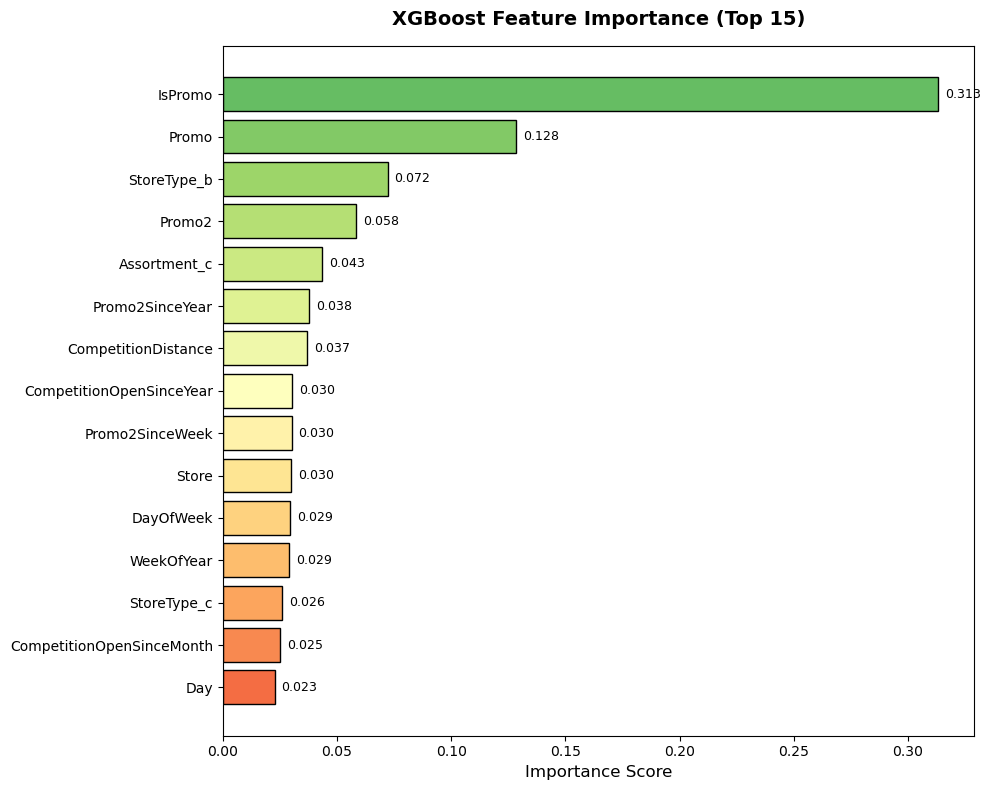

✅ Saved: 07_feature_importance.png


In [9]:
# ============================================================
# CHART 7: FEATURE IMPORTANCE (XGBoost built-in)
# ============================================================

# Get feature importance from XGBoost
importance = xgb_model.feature_importances_
feature_names = X_train.columns

# Sort and get top 15
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importance_df)))
bars = ax.barh(importance_df['feature'], importance_df['importance'], color=colors, edgecolor='black')

ax.set_title('XGBoost Feature Importance (Top 15)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', fontsize=12)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.annotate(f'{width:.3f}',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords="offset points",
                ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{viz_dir}07_feature_importance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: 07_feature_importance.png")



Generating SHAP analysis...


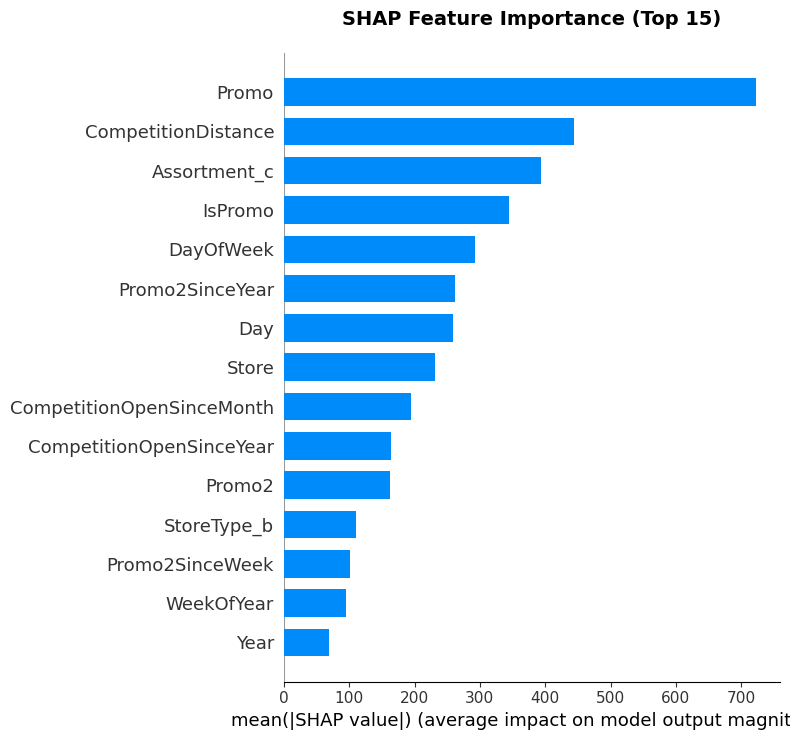

✅ Saved: 08_shap_importance.png


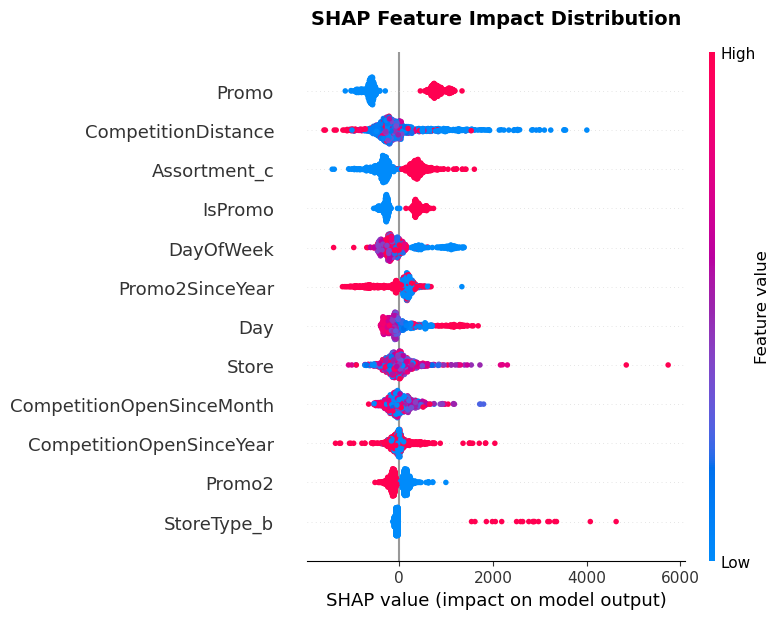

✅ Saved: 09_shap_beeswarm.png


In [10]:
# ============================================================
# CHART 8: SHAP SUMMARY (if shap available)
# ============================================================

try:
    import shap
    
    print("\nGenerating SHAP analysis...")
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_sample.iloc[:1000])
    
    # SHAP bar plot
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_test_sample.iloc[:1000], plot_type="bar", 
                      max_display=15, show=False)
    plt.title('SHAP Feature Importance (Top 15)', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(f'{viz_dir}08_shap_importance.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print("✅ Saved: 08_shap_importance.png")
    
    # SHAP beeswarm
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_test_sample.iloc[:1000], 
                      max_display=12, show=False)
    plt.title('SHAP Feature Impact Distribution', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(f'{viz_dir}09_shap_beeswarm.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print("✅ Saved: 09_shap_beeswarm.png")
    
except ImportError:
    print("⚠️ SHAP not installed. Run: !pip install shap -q")
    print("   Then re-run this cell")

In [11]:
# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*60)
print("VISUALIZATION GENERATION COMPLETE")
print("="*60)
saved_files = os.listdir(viz_dir)
print(f"\n📁 Saved {len(saved_files)} charts to: {viz_dir}")
for f in sorted(saved_files):
    if f.endswith('.png'):
        size_kb = os.path.getsize(os.path.join(viz_dir, f)) / 1024
        print(f"   • {f} ({size_kb:.1f} KB)")
print("="*60)


VISUALIZATION GENERATION COMPLETE

📁 Saved 11 charts to: ../visualization/
   • 01_model_comparison.png (145.1 KB)
   • 02_prediction_vs_actual.png (596.0 KB)
   • 03_sales_by_day.png (140.8 KB)
   • 04_promotion_impact.png (140.6 KB)
   • 05_monthly_trend.png (295.2 KB)
   • 06_residuals_analysis.png (685.6 KB)
   • 07_feature_importance.png (228.7 KB)
   • 08_shap_importance.png (207.4 KB)
   • 09_shap_beeswarm.png (311.7 KB)
